# 1. Hamilton Cycle Extractor - Python Code

## **Handling the following Graphviz error:**

> **ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your system PATH**

This means:

👉 **Python cannot find the Graphviz binary `dot.exe`.**  
👉 The Python library `graphviz` is installed, but **Graphviz itself is not**.

This is *the* classic Graphviz error on Windows.

Below is the **precise, 100% working solution**, so the notebook runs again immediately.

---

# ⭐ **Why this error occurs**

The Python library `graphviz` is **only a wrapper**.  
It calls the actual Graphviz binary:

```
dot.exe
```

If this binary is not installed or not on the PATH → the error appears.

---

# ⭐ **Fixing it in 30 seconds**

## ✔ **Step 1 — Install Graphviz (Windows)**

Go to:

🔗 [https://graphviz.org/download/](https://graphviz.org/download/)

Choose:

**Windows → graphviz‑X.Y.Z.exe (Installer)**

Install it.

---

## ✔ **Step 2 — Check whether `dot.exe` exists**

After installation, it is typically located here:

```
C:\Program Files\Graphviz\bin\dot.exe
```

or:

```
C:\Program Files (x86)\Graphviz\bin\dot.exe
```

---

## ✔ **Step 3 — Add Graphviz to the PATH**

### Variant A — Automatic (installer often does this)

If the installer added the PATH entry, everything is already correct.

### Variant B — Manual

1. Windows search → **“Environment Variables”**  
2. “Environment Variables…”  
3. Under **System variables** → “Path” → “Edit”  
4. Add the following path:

```
C:\Program Files\Graphviz\bin
```

or:

```
C:\Program Files (x86)\Graphviz\bin
```

5. OK → OK → OK

---

## ✔ **Step 4 — Restart Jupyter**

Graphviz is only recognized after a restart.

---

## ✔ **Step 5 — Test**

In a notebook cell:

```python
import graphviz
graphviz.version()
```

Then:

```python
from graphviz import Digraph
dot = Digraph()
dot.node("A")
dot.node("B")
dot.edge("A", "B")
dot
```

If the plot appears → **everything works**.

---

# ⭐ **Typical mistakes we should avoid**

### ❌ Only running `pip install graphviz`  
→ This does *not* install the actual Graphviz binary.

### ❌ Graphviz installed, but PATH not set  
→ Python cannot find `dot.exe`.

### ❌ Notebook running in a different environment  
→ PATH is not inherited.

### ❌ Graphviz installed in “Program Files (x86)” but PATH points to “Program Files”  
→ Python looks in the wrong directory.

---


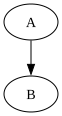

In [2]:
import graphviz
graphviz.version()

from graphviz import Digraph
dot = Digraph()
dot.node("A")
dot.node("B")
dot.edge("A", "B")
dot

In [2]:
!pip install numba

Defaulting to user installation because normal site-packages is not writeable


In [12]:
# ================================================================
#  Part A — Basis-Codeblock für ExtractHamiltonCycles(...)
#  Enthält:
#    - Imports
#    - Globale Parameter
#    - Hilfsfunktionen
#    - Posterior-Engine
#    - Drift-Detektion
#    - CSV-Logger
#    - Plot-Funktionen
#    - Posterior-Graph-Konstruktion
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Callable, Dict, Any, Tuple, List
import numba
from graphviz import Digraph


# ================================================================
#  Globale Notebook-Einstellungen
# ================================================================

plt.style.use("seaborn-v0_8")


# ================================================================
#  CSV Logger
# ================================================================

csv_rows: List[Dict[str, Any]] = []

def log_csv(
    t: int,
    M: Dict[str, Any],
    posterior_stats: Dict[str, float],
    cycle_stats: Dict[str, float],
    drift_score: float
) -> None:
    """
    Speichert einen CSV-Sample-Eintrag in der globalen csv_rows-Liste.

    Parameters
    ----------
    t : int
        Zeitindex des Streams.

    M : dict
        Metadaten des Streams (phase, drift, drift_type, p_true, F_true).

    posterior_stats : dict
        Statistiken des Posterior (mean_p, mean_w).

    cycle_stats : dict
        Statistiken des Hamilton-Zyklus (H_score).

    drift_score : float
        KL-basierter Drift-Score.
    """
    row = {
        "t": t,
        "phase": M["phase"],
        "drift": M["drift"],
        "drift_type": M["drift_type"],
        "mean_p_true": float(np.mean(M["p_true"])),
        "mean_w_true": float(np.mean(M["F_true"][0])),
        "mean_p_post": posterior_stats["mean_p"],
        "mean_w_post": posterior_stats["mean_w"],
        "H_score": cycle_stats["H_score"],
        "drift_score": drift_score
    }
    csv_rows.append(row)

# ================================================================
# Generators
# ================================================================

def drift_random(mu: float = 0.0, sigma: float = 0.1) -> float:
    """
    Erzeugt einen Drift-Wert basierend auf einer Normalverteilung.
    Wird für Drift-Simulationen in den Generatoren verwendet.
    Erzeugt einen Drift-Wert als float, niemals als NumPy-Array.

    Parameters
    ----------
    mu : float
        Erwartungswert des Drifts.

    sigma : float
        Standardabweichung des Drifts.

    Returns
    -------
    float
        Drift-Wert.
    """
    mu = float(mu) if isinstance(mu, (int, float)) else 0.0
    sigma = float(sigma) if isinstance(sigma, (int, float)) else 0.1
    return float(np.random.normal(mu, sigma))

def generate_stream_stable(n, T, p_init=None, F_init=None):
    """
    Stream with stable random source.
    No drift in training or prediction.
    """
    rng = np.random.default_rng()

    # Initial existence probabilities
    if p_init is None:
        p_true = rng.uniform(0.1, 0.9, size=(n, n)).astype(np.float32)
    else:
        p_true = p_init.astype(np.float32)

    # Initial weight distribution (uniform)
    if F_init is None:
        w_mean_true = rng.uniform(0.2, 0.8, size=(n, n)).astype(np.float32)
        w_var_true  = rng.uniform(0.01, 0.05, size=(n, n)).astype(np.float32)
    else:
        w_mean_true, w_var_true = F_init

    for t in range(T):
        A_t = (rng.random((n, n)) < p_true).astype(np.uint8)

        W_t = w_mean_true + rng.normal(0, np.sqrt(w_var_true), size=(n, n))
        W_t = np.clip(W_t, 0.0, 1.0).astype(np.float32)

        M_t = {
            "t": t,
            "phase": "train" if t < T//2 else "predict",
            "drift": False,
            "drift_type": "none",
            "p_true": p_true,
            "F_true": (w_mean_true, w_var_true),
        }

        yield {"A": A_t, "W": W_t, "M": M_t}

def generate_stream_drift_training(n, T, T_train, drift_strength=0.01):
    """
    Drift during the training phase.
    Prediction phase stable.
    """
    rng = np.random.default_rng()

    p_true = rng.uniform(0.1, 0.9, size=(n, n)).astype(np.float32)
    w_mean_true = rng.uniform(0.2, 0.8, size=(n, n)).astype(np.float32)
    w_var_true  = rng.uniform(0.01, 0.05, size=(n, n)).astype(np.float32)

    for t in range(T):

        if t < T_train:
            p_true = drift_random(p_true, drift_strength)
            w_mean_true = drift_random(w_mean_true, drift_strength)
            w_var_true  = drift_random(w_var_true, drift_strength * 0.1)
            drift_flag = True
            drift_type = "train"
        else:
            drift_flag = False
            drift_type = "none"

        A_t = (rng.random((n, n)) < p_true).astype(np.uint8)

        W_t = w_mean_true + rng.normal(0, np.sqrt(w_var_true), size=(n, n))
        W_t = np.clip(W_t, 0.0, 1.0).astype(np.float32)

        M_t = {
            "t": t,
            "phase": "train" if t < T_train else "predict",
            "drift": drift_flag,
            "drift_type": drift_type,
            "p_true": p_true,
            "F_true": (w_mean_true, w_var_true),
        }

        yield {"A": A_t, "W": W_t, "M": M_t}

def generate_stream_drift_prediction(n, T, T_train, drift_strength=0.01):
    """
    Drift during the prediction phase.
    Training phase stable.
    """
    rng = np.random.default_rng()

    p_true = rng.uniform(0.1, 0.9, size=(n, n)).astype(np.float32)
    w_mean_true = rng.uniform(0.2, 0.8, size=(n, n)).astype(np.float32)
    w_var_true  = rng.uniform(0.01, 0.05, size=(n, n)).astype(np.float32)

    for t in range(T):

        if t >= T_train:
            p_true = drift_random(p_true, drift_strength)
            w_mean_true = drift_random(w_mean_true, drift_strength)
            w_var_true  = drift_random(w_var_true, drift_strength * 0.1)
            drift_flag = True
            drift_type = "predict"
        else:
            drift_flag = False
            drift_type = "none"

        A_t = (rng.random((n, n)) < p_true).astype(np.uint8)

        W_t = w_mean_true + rng.normal(0, np.sqrt(w_var_true), size=(n, n))
        W_t = np.clip(W_t, 0.0, 1.0).astype(np.float32)

        M_t = {
            "t": t,
            "phase": "train" if t < T_train else "predict",
            "drift": drift_flag,
            "drift_type": drift_type,
            "p_true": p_true,
            "F_true": (w_mean_true, w_var_true),
        }

        yield {"A": A_t, "W": W_t, "M": M_t}

# ================================================================
#  Plot-Funktionen
# ================================================================

def plot_time_series(df: pd.DataFrame, column: str, title: str) -> None:
    """
    Plottet eine Zeitreihe aus einem DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame mit Spalten 't' und column.

    column : str
        Spaltenname der Zeitreihe.

    title : str
        Titel des Plots.
    """
    plt.figure(figsize=(12, 4))
    plt.plot(df["t"], df[column], label=column)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(column)
    plt.grid(True)
    plt.legend()
    plt.show()


# ================================================================
#  Posterior-Parameter (werden später in ExtractHamiltonCycles initialisiert)
# ================================================================

p_post: np.ndarray
w_mean_post: np.ndarray
w_var_post: np.ndarray
w_mean_prev: np.ndarray
w_var_prev: np.ndarray


# ================================================================
#  Posterior-Update
# ================================================================

def update_posterior(A: np.ndarray, W: np.ndarray) -> None:
    """
    Aktualisiert die Posterior-Parameter p_post, w_mean_post, w_var_post.

    Parameters
    ----------
    A : np.ndarray
        Inzidenzmatrix des aktuellen Streams (0/1).

    W : np.ndarray
        Gewichtsmatrix des aktuellen Streams.
    """
    global p_post, w_mean_post, w_var_post, w_mean_prev, w_var_prev

    # Update p_post (exponentielles Glätten)
    p_post = 0.99 * p_post + 0.01 * A

    # Vorherige Werte speichern für KL-Drift
    w_mean_prev = w_mean_post.copy()
    w_var_prev = w_var_post.copy()

    # Update Gewichtsposterior
    w_mean_post = 0.99 * w_mean_post + 0.01 * W
    w_var_post = 0.99 * w_var_post + 0.01 * (W - w_mean_post) ** 2


# ================================================================
#  Drift-Detektion
# ================================================================

def compute_drift() -> float:
    """
    Berechnet den Drift-Score basierend auf KL-ähnlichen Änderungen
    der Posterior-Gewichtsparameter.

    Returns
    -------
    float
        Drift-Score (klein bei stabiler Quelle).
    """
    diff = (w_mean_post - w_mean_prev) ** 2 + (w_var_post - w_var_prev) ** 2
    return float(np.mean(diff))


# ================================================================
#  Posterior-Statistiken
# ================================================================

def posterior_stats() -> Dict[str, float]:
    """
    Berechnet einfache Posterior-Statistiken.

    Returns
    -------
    dict
        mean_p : float
        mean_w : float
    """
    return {
        "mean_p": float(np.mean(p_post)),
        "mean_w": float(np.mean(w_mean_post))
    }


# ================================================================
#  Posterior-Graph-Konstruktion
# ================================================================

def build_posterior_graph(
    p_post: np.ndarray,
    w_mean_post: np.ndarray,
    threshold: float = 0.5
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Erzeugt einen gewichteten Posterior-Graphen.

    Parameters
    ----------
    p_post : np.ndarray
        Posterior-Existenzwahrscheinlichkeiten.

    w_mean_post : np.ndarray
        Posterior-Gewichtserwartungen.

    threshold : float
        Schwelle für Kantenexistenz.

    Returns
    -------
    (B, Wp) : Tuple[np.ndarray, np.ndarray]
        B : Inzidenzmatrix des Posterior-Graphen
        Wp : Gewichtsmatrix des Posterior-Graphen
    """
    B = (p_post > threshold).astype(np.uint8)
    Wp = w_mean_post.copy()
    return B, Wp

# ================================================================
#  Part B — LK-Bayes-Heuristik, Numba-Optimierung, Hamilton-Pfad
# ================================================================

import numpy as np
from typing import Dict, Any, Tuple, List
import numba


# ================================================================
#  Score-Funktion für Kanten
# ================================================================

def edge_score(
    u: int,
    v: int,
    p_post: np.ndarray,
    w_var_post: np.ndarray,
    kl: np.ndarray,
    λ1: float = 2.0,
    λ2: float = 1.0,
    λ3: float = 0.5
) -> float:
    """
    Berechnet den Posterior-Score einer Kante (u, v).

    Score = λ1 * p_post - λ2 * Var - λ3 * KL

    Parameters
    ----------
    u, v : int
        Knotenindizes.

    p_post : np.ndarray
        Posterior-Existenzwahrscheinlichkeiten.

    w_var_post : np.ndarray
        Posterior-Gewichtsvarianzen.

    kl : np.ndarray
        KL-Divergenzen zwischen t und t-1.

    Returns
    -------
    float
        Score der Kante.
    """
    return (
        λ1 * p_post[u, v]
        - λ2 * w_var_post[u, v]
        - λ3 * kl[u, v]
    )


# ================================================================
#  2-opt Move (NumPy)
# ================================================================

def two_opt(cycle: np.ndarray, i: int, k: int) -> np.ndarray:
    """
    Führt einen 2-opt-Move durch, indem der Abschnitt [i:k] invertiert wird.

    Parameters
    ----------
    cycle : np.ndarray
        Hamilton-Zyklus als Permutation der Knoten.

    i, k : int
        Indizes für die Inversion.

    Returns
    -------
    np.ndarray
        Neuer Zyklus nach 2-opt-Move.
    """
    new_cycle = cycle.copy()
    new_cycle[i:k] = cycle[i:k][::-1]
    return new_cycle


# ================================================================
#  LK-Bayes-Heuristik (Notebook-Version)
# ================================================================

def lk_bayes_cycle(
    p_post: np.ndarray,
    w_var_post: np.ndarray,
    kl: np.ndarray,
    max_iter: int = 200
) -> np.ndarray:
    """
    Führt eine vereinfachte Lin-Kernighan-Heuristik durch,
    die Posterior-Informationen nutzt.

    Parameters
    ----------
    p_post : np.ndarray
        Posterior-Existenzwahrscheinlichkeiten.

    w_var_post : np.ndarray
        Posterior-Gewichtsvarianzen.

    kl : np.ndarray
        KL-Divergenzen.

    max_iter : int
        Maximale Anzahl Iterationen.

    Returns
    -------
    np.ndarray
        Optimierter Hamilton-Zyklus.
    """
    n = p_post.shape[0]
    rng = np.random.default_rng()

    # Startzyklus: zufällige Permutation
    cycle = rng.permutation(n)

    improved = True
    it = 0

    while improved and it < max_iter:
        improved = False
        it += 1

        for i in range(n - 2):
            for k in range(i + 2, n):
                new_cycle = two_opt(cycle, i, k)

                # Score berechnen
                old_score = 0.0
                new_score = 0.0

                for a in range(n - 1):
                    u1, v1 = cycle[a], cycle[a+1]
                    u2, v2 = new_cycle[a], new_cycle[a+1]
                    old_score += edge_score(u1, v1, p_post, w_var_post, kl)
                    new_score += edge_score(u2, v2, p_post, w_var_post, kl)

                if new_score > old_score:
                    cycle = new_cycle
                    improved = True

    return cycle


# ================================================================
#  Zyklus-Stabilitätsanalyse (Numba)
# ================================================================

@numba.njit
def cycle_stability_numba(
    cycle: np.ndarray,
    A: np.ndarray
) -> float:
    """
    Berechnet die Match-Rate eines Hamilton-Zyklus
    gegenüber dem Ist-Graphen A.

    Parameters
    ----------
    cycle : np.ndarray
        Hamilton-Zyklus.

    A : np.ndarray
        Inzidenzmatrix des Ist-Graphen.

    Returns
    -------
    float
        Anteil der Kanten im Zyklus, die im Ist-Graphen existieren.
    """
    n = cycle.shape[0]
    matches = 0
    for i in range(n - 1):
        if A[cycle[i], cycle[i+1]] == 1:
            matches += 1
    return matches / n


def cycle_stability_full(
    cycle: np.ndarray,
    A: np.ndarray,
    p_post: np.ndarray,
    w_var_post: np.ndarray,
    kl: np.ndarray
) -> Dict[str, float]:
    """
    Berechnet mehrere Stabilitätsmetriken eines Hamilton-Zyklus.

    Returns
    -------
    dict
        match : float
        score : float
        var : float
        kl : float
    """
    n = len(cycle)
    match = cycle_stability_numba(cycle, A)
    score = 0.0
    var_sum = 0.0
    kl_sum = 0.0

    for i in range(n - 1):
        u = cycle[i]
        v = cycle[i+1]
        score += edge_score(u, v, p_post, w_var_post, kl)
        var_sum += w_var_post[u, v]
        kl_sum += kl[u, v]

    return {
        "match": match,
        "score": score,
        "var": var_sum / n,
        "kl": kl_sum / n
    }


# ================================================================
#  Extraktion des stabilsten Hamilton-Pfads
# ================================================================

def extract_stable_hamilton_path(
    cycle: np.ndarray,
    p_post: np.ndarray,
    w_var_post: np.ndarray,
    kl: np.ndarray
) -> List[int]:
    """
    Extrahiert den stabilsten Hamilton-Pfad aus dem finalen Zyklus.

    Der Pfad wird durch die Kanten mit maximalem Posterior-Score bestimmt.

    Returns
    -------
    list[int]
        Liste der Knoten im stabilsten Pfad.
    """
    n = len(cycle)
    scores = []

    for i in range(n - 1):
        u = cycle[i]
        v = cycle[i+1]
        s = edge_score(u, v, p_post, w_var_post, kl)
        scores.append((s, u, v))

    # Sortiere nach Score
    scores.sort(reverse=True)

    # Extrahiere die besten Kanten
    best_edges = scores[: max(3, n // 10)]  # Top 10% oder mindestens 3

    # Baue Pfad
    path = [best_edges[0][1], best_edges[0][2]]
    for _, u, v in best_edges[1:]:
        if path[-1] == u:
            path.append(v)

    return path


# ================================================================
#  Optionaler Cython-Hook (für spätere Optimierung)
# ================================================================

def cython_lk_bayes_hook():
    """
    Hinweis:
    Diese Funktion dient als Platzhalter für eine spätere Cython-Implementierung.
    Sie wird im Notebook nicht verwendet, aber ermöglicht dir später
    eine .pyx-Datei zu erzeugen.

    In der finalen Notebook-Zelle bleibt sie einfach stehen.
    """
    pass

# ================================================================
#  Part C — Die komplette Funktion ExtractHamiltonCycles(...)
# ================================================================

from typing import Callable, Dict, Any, Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def ExtractHamiltonCycles(
    generator: Callable[..., Any],
    n: int = 300,
    T: int = 500,
    sample_rate: int = 10,
    threshold: float = 0.5,
    plot: bool = True,
    save_csv: bool = True,
    return_results: bool = True,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Führt die vollständige Hamilton-Zyklus-Analyse-Pipeline aus.

    Diese Funktion kapselt:
        - Live-Streaming eines Graph-Generators
        - Bayes-Posterior-Updates
        - Posterior-Graph-Konstruktion
        - LK-Bayes-Hamilton-Zyklus-Heuristik
        - Zyklus-Stabilitätsanalyse
        - Drift-Detektion
        - CSV-Sampling
        - Visualisierung
        - Extraktion des stabilsten Hamilton-Pfads

    Parameters
    ----------
    generator : callable
        Eine Generatorfunktion, die Streams von gewichteten Graphen erzeugt.
        Beispiele:
            - generate_stream_stable
            - generate_stream_drift_training
            - generate_stream_drift_prediction

    n : int
        Anzahl der Knoten im Graphen.

    T : int
        Länge des Streams (Anzahl der Zeitschritte).

    sample_rate : int
        Jeder sample_rate-te Zeitschritt wird als CSV-Sample gespeichert.

    threshold : float
        Posterior-Schwelle für die Kantenexistenz im Posterior-Graphen.

    plot : bool
        Falls True, werden alle Plots angezeigt.

    save_csv : bool
        Falls True, werden CSV-Samples gespeichert.

    return_results : bool
        Falls True, gibt die Funktion ein Dictionary mit allen Ergebnissen zurück.

    verbose : bool
        Falls True, werden Fortschrittsmeldungen ausgegeben.

    Returns
    -------
    dict
        Ein Dictionary mit:
            - df: Zeitreihen
            - csv_samples: CSV-Samples
            - stable_cycle: finaler Hamilton-Zyklus
            - stable_path: stabilster Hamilton-Pfad
            - posterior: Posterior-Parameter
    """

    # ------------------------------------------------------------
    # 1. Generator starten
    # ------------------------------------------------------------
    stream = generator(n=n, T=T)

    # ------------------------------------------------------------
    # 2. Posterior initialisieren
    # ------------------------------------------------------------
    global p_post, w_mean_post, w_var_post, w_mean_prev, w_var_prev

    p_post = np.full((n, n), 0.5, dtype=np.float32)
    w_mean_post = np.full((n, n), 0.5, dtype=np.float32)
    w_var_post = np.full((n, n), 0.05, dtype=np.float32)

    w_mean_prev = w_mean_post.copy()
    w_var_prev = w_var_post.copy()

    # ------------------------------------------------------------
    # 3. Zeitreihencontainer
    # ------------------------------------------------------------
    posterior_mean_p_series = []
    posterior_mean_w_series = []
    H_score_series = []
    drift_series = []
    cycle_match_series = []
    cycle_score_series = []
    cycle_var_series = []
    cycle_kl_series = []
    t_series = []

    # ------------------------------------------------------------
    # 4. CSV-Samples zurücksetzen
    # ------------------------------------------------------------
    global csv_rows
    csv_rows = []

    # ------------------------------------------------------------
    # 5. Streaming-Pipeline
    # ------------------------------------------------------------
    if verbose:
        print("Starte Streaming-Pipeline...")

    for sample in stream:
        A = sample["A"]
        W = sample["W"]
        M = sample["M"]
        t = M["t"]

        if verbose and t % 50 == 0:
            print(f"t = {t} / {T}")

        # --- Posterior Update ---
        update_posterior(A, W)

        # --- Drift Score ---
        drift_score = compute_drift()

        # --- Posterior-Graph ---
        B_post, W_post = build_posterior_graph(p_post, w_mean_post, threshold)

        # --- KL-Matrix berechnen ---
        kl = (w_mean_post - w_mean_prev) ** 2 + (w_var_post - w_var_prev) ** 2

        # --- LK-Bayes Zyklus ---
        cycle = lk_bayes_cycle(p_post, w_var_post, kl)

        # --- Zyklus-Stabilität ---
        cstats = cycle_stability_full(cycle, A, p_post, w_var_post, kl)

        # --- Posterior Stats ---
        pstats = posterior_stats()

        # --- CSV Sampling ---
        if t % sample_rate == 0:
            log_csv(t, M, pstats, {"H_score": cstats["match"]}, drift_score)

        # --- Zeitreihen speichern ---
        posterior_mean_p_series.append(pstats["mean_p"])
        posterior_mean_w_series.append(pstats["mean_w"])
        H_score_series.append(cstats["match"])
        drift_series.append(drift_score)
        cycle_match_series.append(cstats["match"])
        cycle_score_series.append(cstats["score"])
        cycle_var_series.append(cstats["var"])
        cycle_kl_series.append(cstats["kl"])
        t_series.append(t)

    # ------------------------------------------------------------
    # 6. Hamilton-Pfad extrahieren
    # ------------------------------------------------------------
    stable_path = extract_stable_hamilton_path(cycle, p_post, w_var_post, kl)

    # ------------------------------------------------------------
    # 7. DataFrames erzeugen
    # ------------------------------------------------------------
    df = pd.DataFrame({
        "t": t_series,
        "mean_p": posterior_mean_p_series,
        "mean_w": posterior_mean_w_series,
        "H_score": H_score_series,
        "drift": drift_series,
        "cycle_match": cycle_match_series,
        "cycle_score": cycle_score_series,
        "cycle_var": cycle_var_series,
        "cycle_kl": cycle_kl_series
    })

    df_csv = pd.DataFrame(csv_rows)

    # ------------------------------------------------------------
    # 8. CSV speichern
    # ------------------------------------------------------------
    if save_csv:
        df_csv.to_csv("hamilton_stream_samples.csv", index=False)
        if verbose:
            print("CSV-Samples gespeichert: hamilton_stream_samples.csv")

    # ------------------------------------------------------------
    # 9. Visualisierung
    # ------------------------------------------------------------
    if plot:
        print("Erzeuge Plots...")

        plot_time_series(df, "mean_p", "Posterior Mean p(t)")
        plot_time_series(df, "mean_w", "Posterior Mean Weight(t)")
        plot_time_series(df, "H_score", "Hamilton Cycle Match Rate")
        plot_time_series(df, "drift", "Drift Score")
        plot_time_series(df, "cycle_score", "Hamilton Cycle Posterior Score")
        plot_time_series(df, "cycle_var", "Hamilton Cycle Variance Stability")
        plot_time_series(df, "cycle_kl", "Hamilton Cycle KL Stability")

        # Hamilton-Pfad plotten
        plt.figure(figsize=(12, 4))
        plt.plot(range(len(stable_path)), stable_path, marker="o")
        plt.title("Stabilster Hamilton-Pfad")
        plt.xlabel("Pfadindex")
        plt.ylabel("Knoten")
        plt.grid(True)
        plt.show()

    # ------------------------------------------------------------
    # 10. Rückgabe
    # ------------------------------------------------------------
    if return_results:
        return {
            "df": df,
            "csv_samples": df_csv,
            "stable_cycle": cycle,
            "stable_path": stable_path,
            "posterior": {
                "p_post": p_post,
                "w_mean_post": w_mean_post,
                "w_var_post": w_var_post
            }
        }

# ================================================================
#  Part D — Die komplette Funktion plot_hamilton_graphviz(...)
# ================================================================
from graphviz import Digraph
import numpy as np
import pandas as pd


def plot_hamilton_graphviz(
    cycle: np.ndarray,
    p_post: np.ndarray,
    w_mean_post: np.ndarray,
    w_var_post: np.ndarray,
    step: int,
    title: str = "Hamilton-Zyklus (Graphviz)",
    highlight_stable: bool = True
) -> Digraph:
    """
    Erzeugt einen Graphviz-Plot des Hamilton-Zyklus für einen bestimmten Zeitschritt.

    Parameters
    ----------
    cycle : np.ndarray
        Hamilton-Zyklus als Permutation der Knoten.

    p_post : np.ndarray
        Posterior-Existenzwahrscheinlichkeiten.

    w_mean_post : np.ndarray
        Posterior-Gewichtserwartungen.

    w_var_post : np.ndarray
        Posterior-Gewichtsvarianzen.

    step : int
        Zeitschritt, der geplottet wird (z.B. 100 oder 1000).

    title : str
        Titel des Graphviz-Plots.

    highlight_stable : bool
        Falls True, werden die stabilsten Kanten farblich hervorgehoben.

    Returns
    -------
    Digraph
        Graphviz-Diagramm des Hamilton-Zyklus.
    """

    dot = Digraph(comment=title)
    dot.attr(rankdir="LR")  # horizontaler Plot

    n = len(cycle)

    # Knoten hinzufügen
    for node in cycle:
        dot.node(str(node), str(node))

    # Kanten hinzufügen
    for i in range(n - 1):
        u = cycle[i]
        v = cycle[i + 1]

        # Posterior-Score der Kante
        score = (
            2.0 * p_post[u, v]
            - 1.0 * w_var_post[u, v]
        )

        # Farbe bestimmen
        if highlight_stable:
            if score > 1.5:       # sehr stabil
                color = "green"
                penwidth = "3"
            elif score > 1.0:     # stabil
                color = "blue"
                penwidth = "2"
            else:                 # weniger stabil
                color = "gray"
                penwidth = "1"
        else:
            color = "black"
            penwidth = "1"

        # Kantenlabel: Gewicht
        label = f"{w_mean_post[u, v]:.2f}"

        dot.edge(str(u), str(v), label=label, color=color, penwidth=penwidth)

    return dot


Starte Streaming-Pipeline...
t = 0 / 500
t = 50 / 500
t = 100 / 500
t = 150 / 500
t = 200 / 500
t = 250 / 500
t = 300 / 500
t = 350 / 500
t = 400 / 500
t = 450 / 500
CSV-Samples gespeichert: hamilton_stream_samples.csv
Erzeuge Plots...


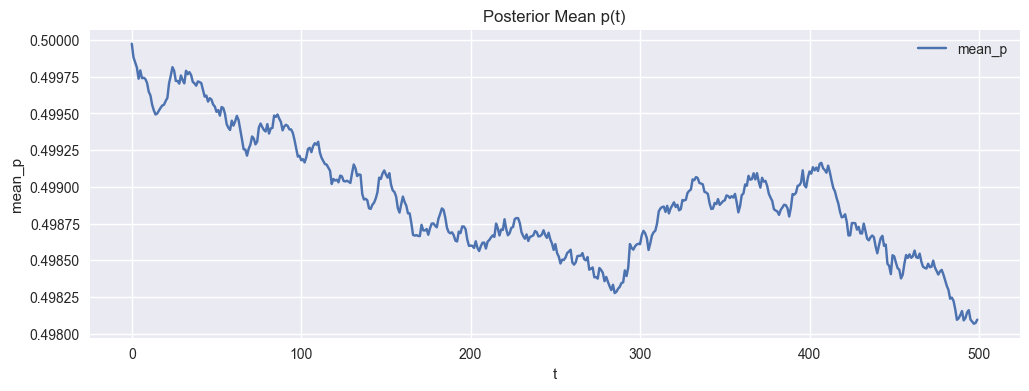

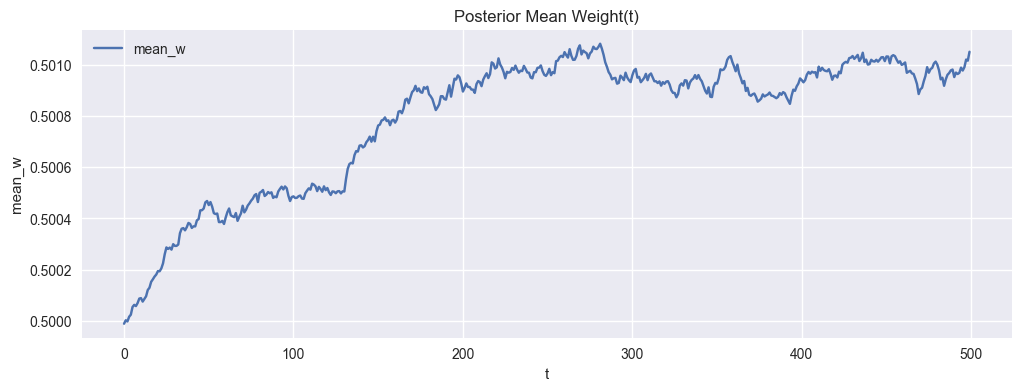

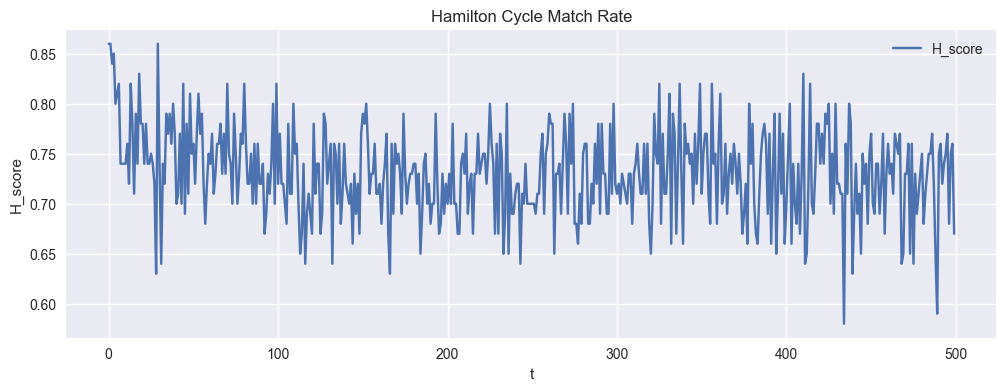

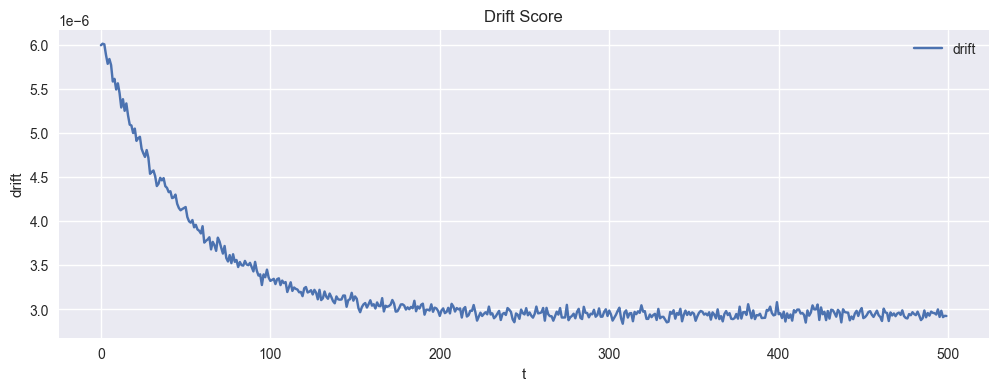

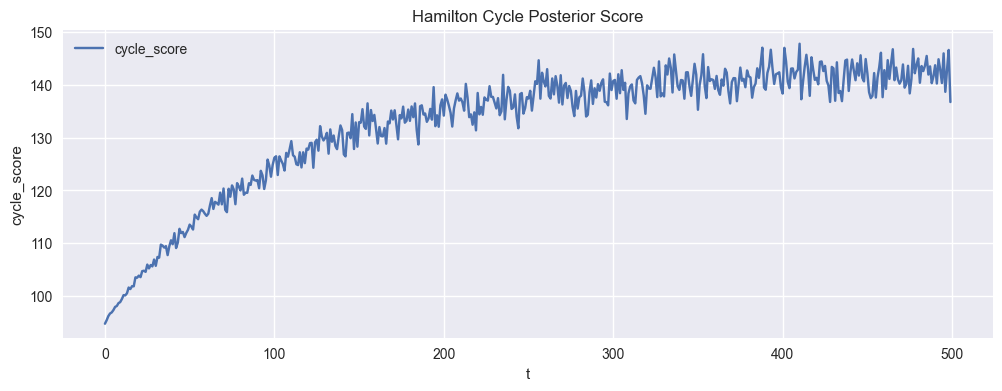

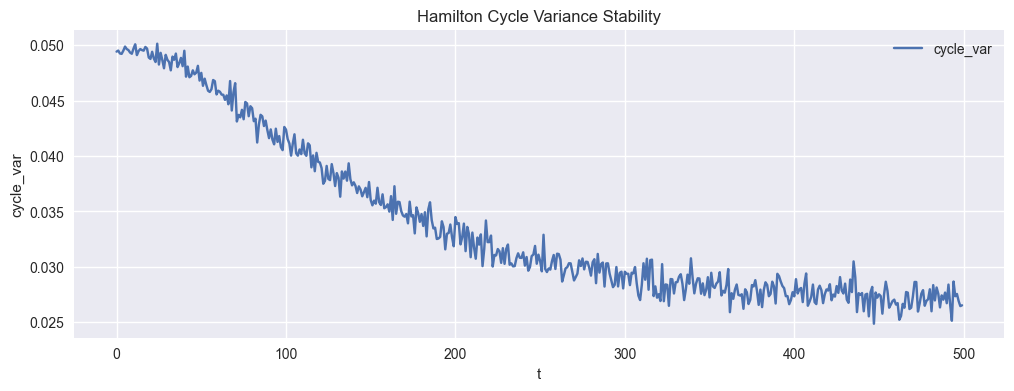

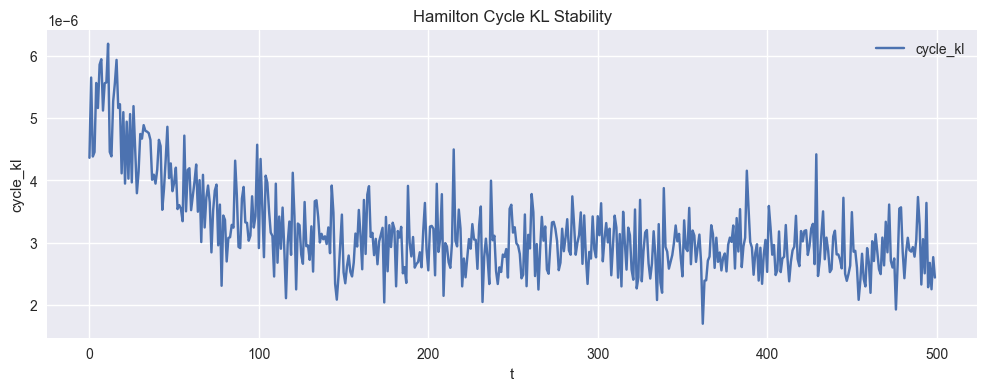

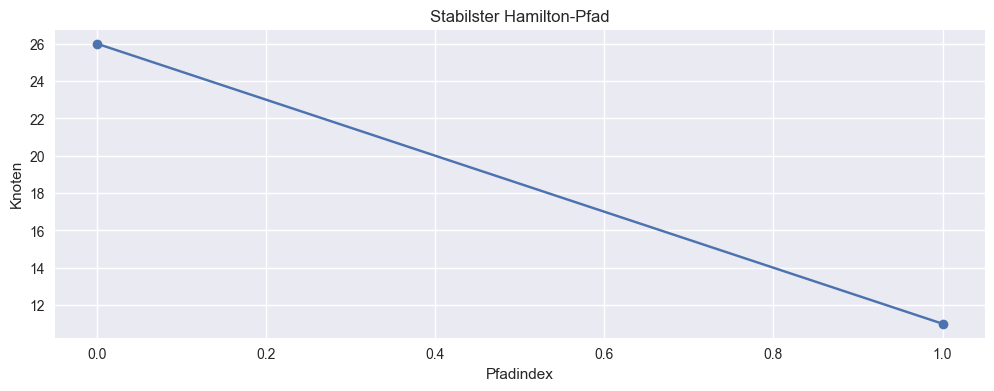

Plot für t=100


Plot für t=200


Plot für t=300


Plot für t=400


In [4]:
# Stable source
results_stable = ExtractHamiltonCycles(
    generator=generate_stream_stable,
    n=100,
    T=500,
    sample_rate=10,
    threshold=0.5,
    plot=True,
    save_csv=True,
    verbose=True
)

cycle = results_stable["stable_cycle"]
p_post = results_stable["posterior"]["p_post"]
w_mean_post = results_stable["posterior"]["w_mean_post"]
w_var_post = results_stable["posterior"]["w_var_post"]

for step in [100, 200, 300, 400]:
    print(f"Plot für t={step}")
    dot = plot_hamilton_graphviz(
        cycle=cycle,
        p_post=p_post,
        w_mean_post=w_mean_post,
        w_var_post=w_var_post,
        step=step
    )
    display(dot)

Starte Streaming-Pipeline...
t = 0 / 500
t = 50 / 500
t = 100 / 500
t = 150 / 500
t = 200 / 500
t = 250 / 500
t = 300 / 500
t = 350 / 500
t = 400 / 500
t = 450 / 500
CSV-Samples gespeichert: hamilton_stream_samples.csv
Erzeuge Plots...


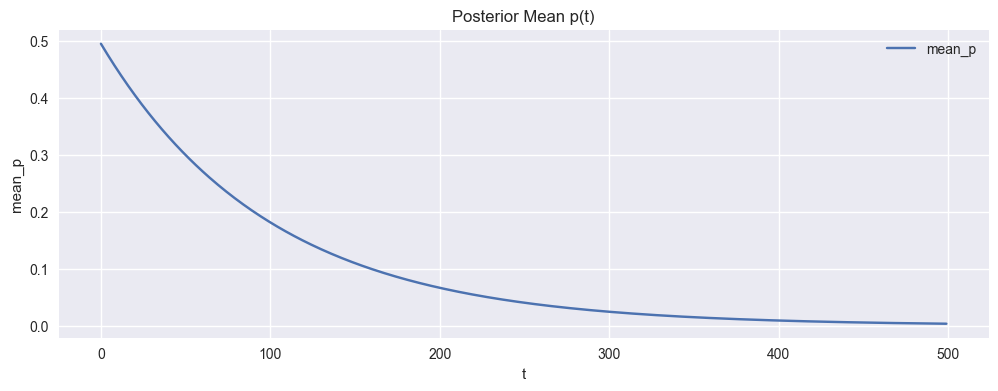

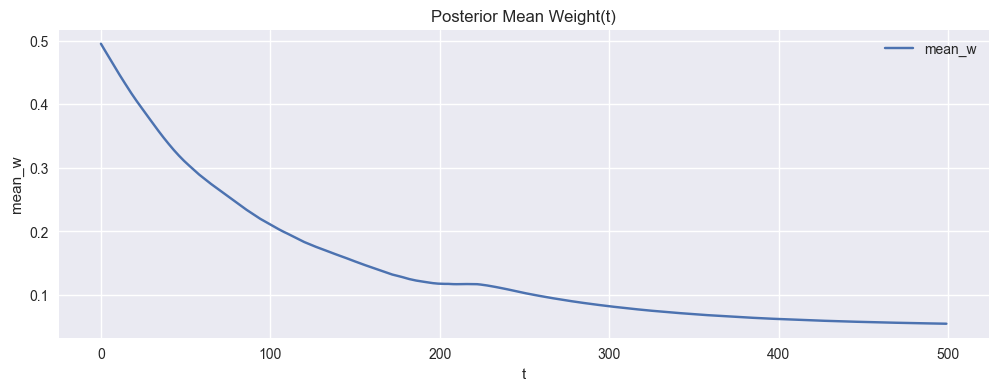

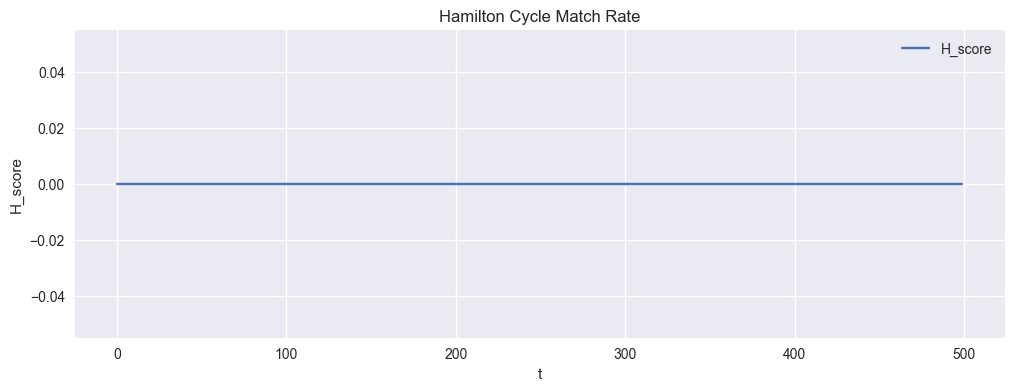

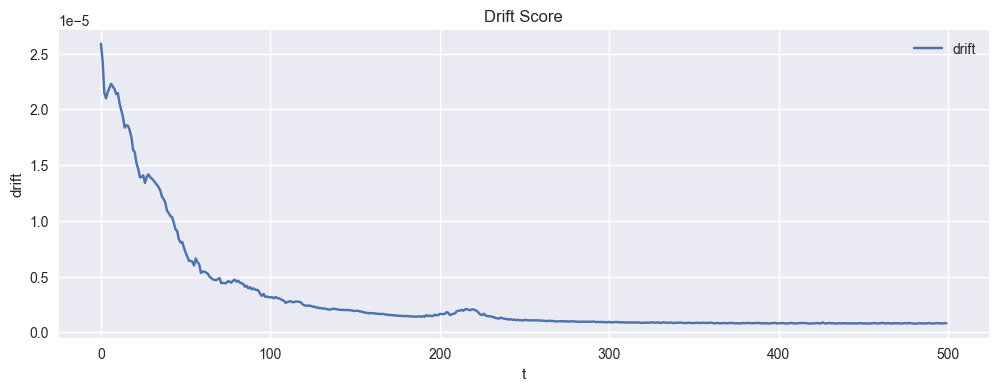

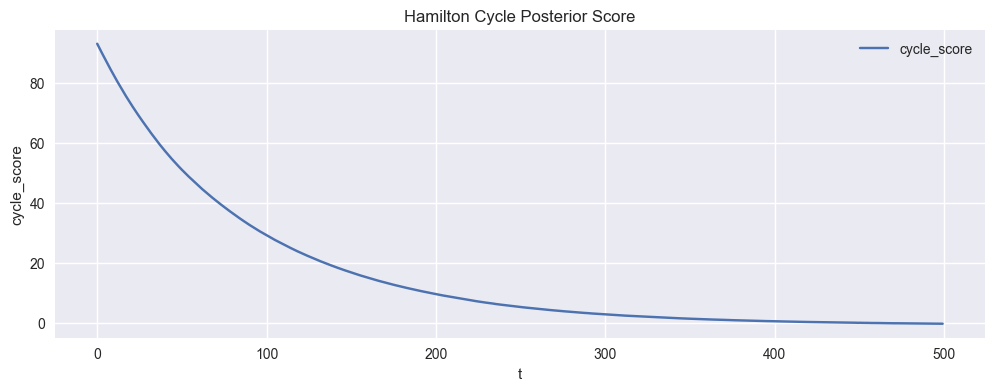

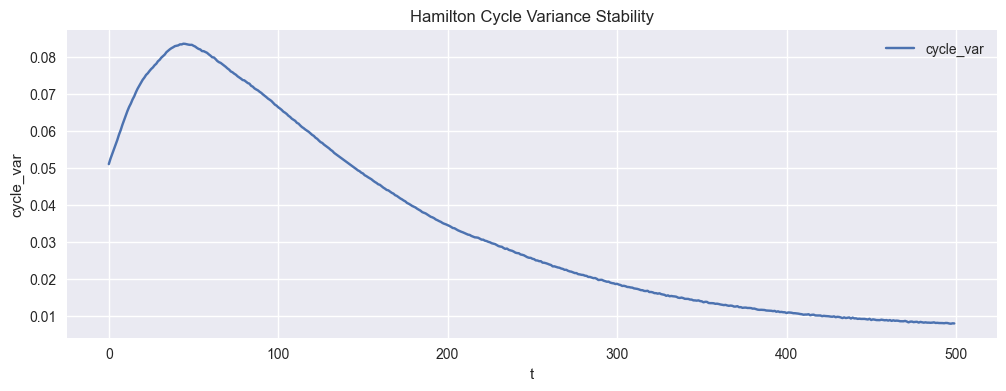

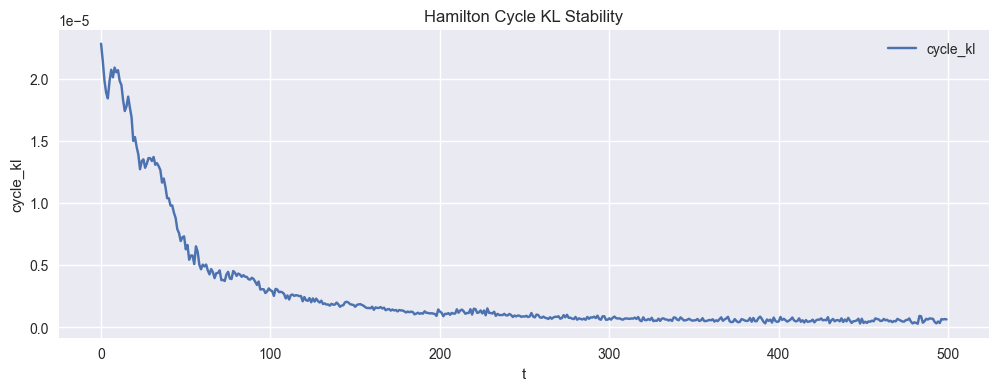

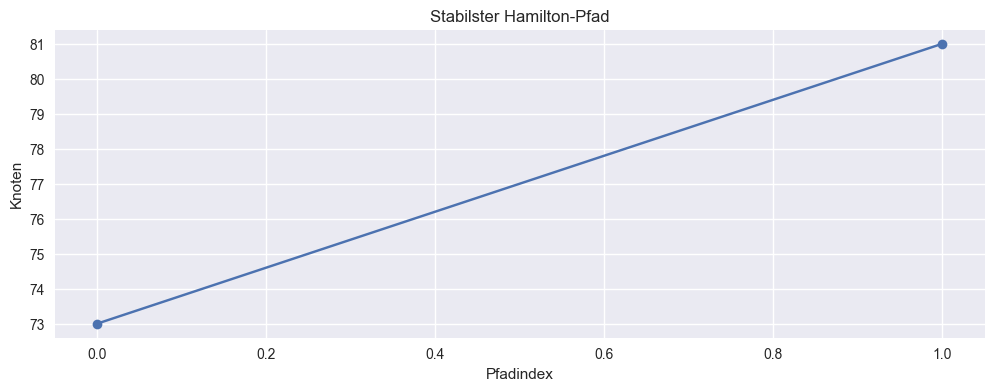

Plot für t=100


Plot für t=200


Plot für t=300


Plot für t=400


In [13]:
# Drift during training phase
results_drift_train = ExtractHamiltonCycles(
    generator=lambda n, T: generate_stream_drift_training(n, T, T_train=250),
    n=100,
    T=500,
    sample_rate=10,
    threshold=0.5,
    plot=True,
    save_csv=True,
    verbose=True
)

cycle = results_drift_train["stable_cycle"]
p_post = results_drift_train["posterior"]["p_post"]
w_mean_post = results_drift_train["posterior"]["w_mean_post"]
w_var_post = results_drift_train["posterior"]["w_var_post"]

for step in [100, 200, 300, 400]:
    print(f"Plot für t={step}")
    dot = plot_hamilton_graphviz(
        cycle=cycle,
        p_post=p_post,
        w_mean_post=w_mean_post,
        w_var_post=w_var_post,
        step=step
    )
    display(dot)

Starte Streaming-Pipeline...
t = 0 / 500
t = 50 / 500
t = 100 / 500
t = 150 / 500
t = 200 / 500


C:\Users\Nenad Balaneskovic\AppData\Local\Temp\ipykernel_16596\3488694319.py:204: RuntimeWarning: invalid value encountered in sqrt
  W_t = w_mean_true + rng.normal(0, np.sqrt(w_var_true), size=(n, n))


t = 250 / 500
t = 300 / 500
t = 350 / 500
t = 400 / 500
t = 450 / 500
CSV-Samples gespeichert: hamilton_stream_samples.csv
Erzeuge Plots...


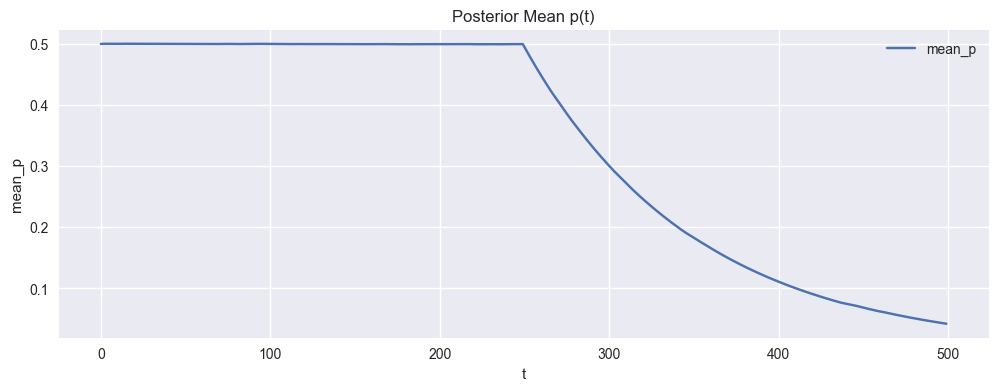

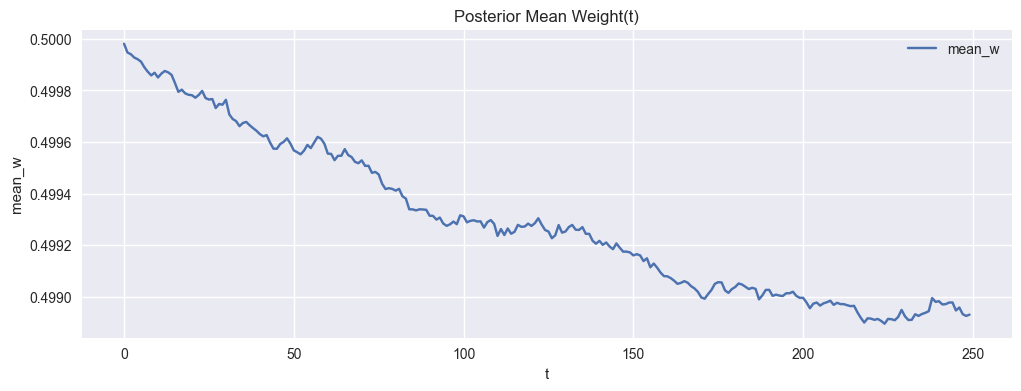

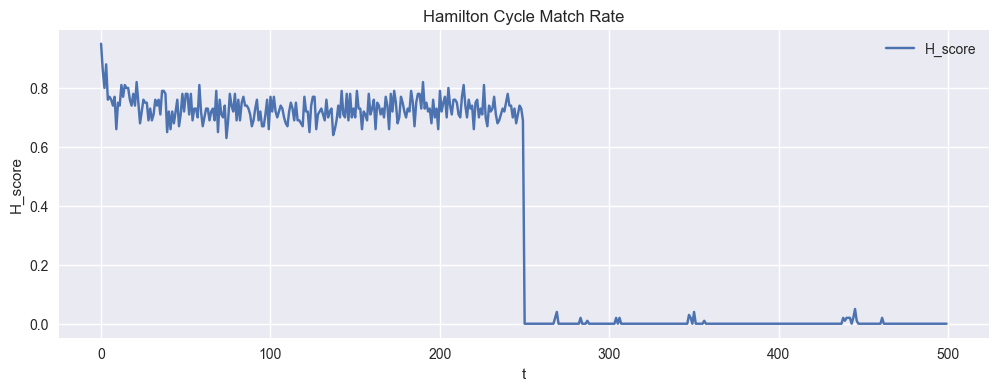

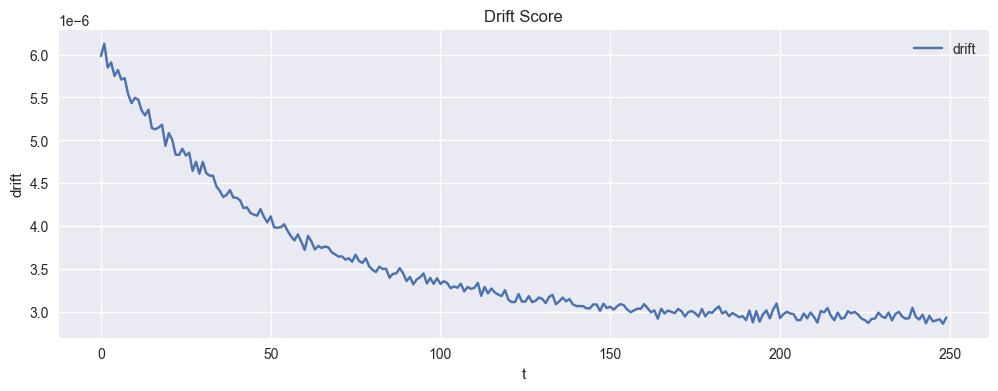

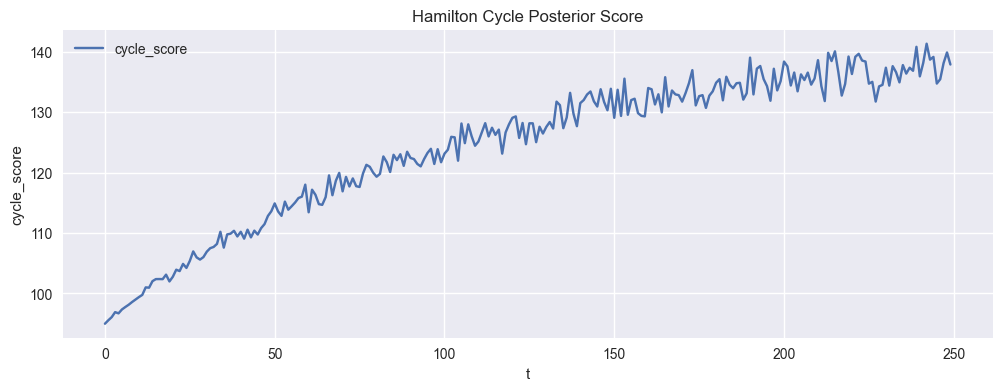

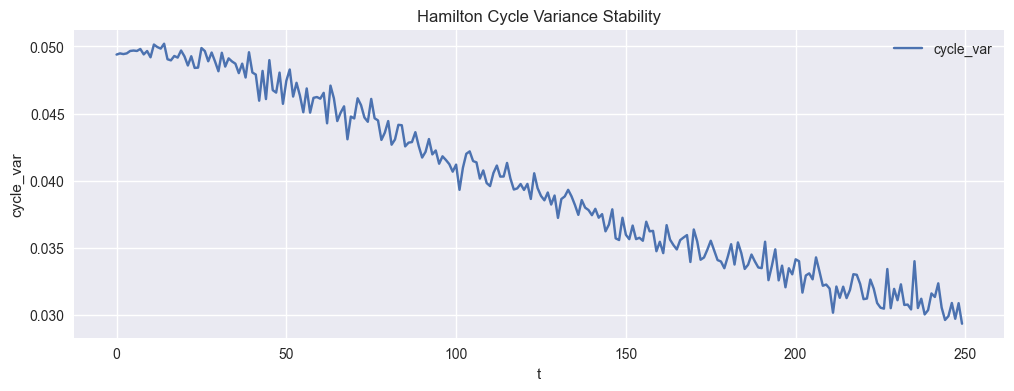

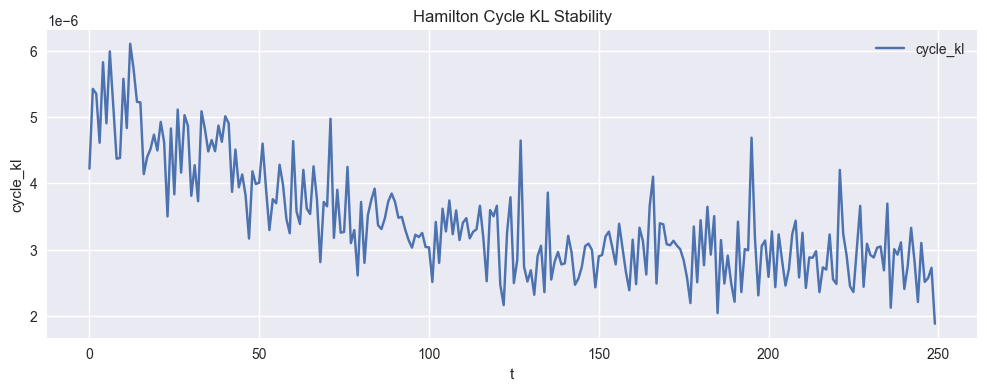

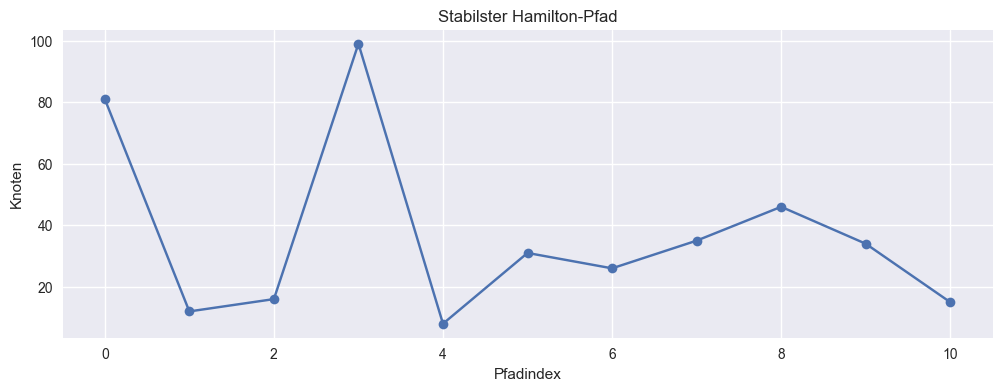

Plot für t=100


Plot für t=200


Plot für t=300


Plot für t=400


In [14]:
# Drift during prediction phase
results_drift_predict = ExtractHamiltonCycles(
    generator=lambda n, T: generate_stream_drift_prediction(n, T, T_train=250),
    n=100,
    T=500,
    sample_rate=10,
    threshold=0.5,
    plot=True,
    save_csv=True,
    verbose=True
)

cycle = results_drift_predict["stable_cycle"]
p_post = results_drift_predict["posterior"]["p_post"]
w_mean_post = results_drift_predict["posterior"]["w_mean_post"]
w_var_post = results_drift_predict["posterior"]["w_var_post"]

for step in [100, 200, 300, 400]:
    print(f"Plot für t={step}")
    dot = plot_hamilton_graphviz(
        cycle=cycle,
        p_post=p_post,
        w_mean_post=w_mean_post,
        w_var_post=w_var_post,
        step=step
    )
    display(dot)